# Grid filter

In [ ]:
# Filter CASSCF grid structures with high relative energies or forces.

from pathlib import Path

import ase.io
import numpy as np

input_path = Path("../data/azoflip_data/XYZ/azobenzene_grid_static_CASSCF.xyz")
output_path = input_path.with_name(f"{input_path.stem}_energy_forces_filtered.xyz")
ENERGY_CUTOFF_EV = 30.0
FORCE_CUTOFF_EV_PER_ANGSTROM = 100.0

frames = ase.io.read(input_path, index=":")
if not frames:
    raise ValueError(f"No structures found in {input_path}")

energies_ev = np.vstack([
    np.asarray(frame.info["REF_energy"], dtype=float).reshape(-1) for frame in frames
])
forces_ev_per_angstrom = np.stack([
    np.asarray(frame.info["REF_forces"], dtype=float) for frame in frames
])
if forces_ev_per_angstrom.shape[:3] != (len(frames), len(frames[0]), energies_ev.shape[1]):
    raise ValueError("REF_forces must have shape (frames, atoms, states, 3).")

relative_energies_ev = energies_ev - energies_ev.min(axis=0, keepdims=True)
max_force_norm_ev_per_angstrom = np.linalg.norm(forces_ev_per_angstrom, axis=-1).max(axis=(1, 2))
energy_outlier = np.any(relative_energies_ev > ENERGY_CUTOFF_EV, axis=1)
force_outlier = max_force_norm_ev_per_angstrom > FORCE_CUTOFF_EV_PER_ANGSTROM
keep_mask = ~(energy_outlier | force_outlier)
filtered_frames = [frame for frame, keep in zip(frames, keep_mask) if keep]
if not filtered_frames:
    raise ValueError("All frames were rejected by the energy/force filter.")

ase.io.write(output_path, filtered_frames, format="extxyz")

print(f"Input frames: {len(frames):,}")
print(f"Removed: {np.count_nonzero(~keep_mask):,} ({np.mean(~keep_mask):.2%})")
print(f"  Energy-only: {np.count_nonzero(energy_outlier & ~force_outlier):,}")
print(f"  Force-only: {np.count_nonzero(force_outlier & ~energy_outlier):,}")
print(f"  Both: {np.count_nonzero(energy_outlier & force_outlier):,}")
print(f"Retained: {len(filtered_frames):,}")
print(f"Wrote filtered structures to {output_path}")


Input frames: 11,319
Removed: 341 (3.01%)
  Energy-only: 43
  Force-only: 6
  Both: 292
Retained: 10,978
Wrote filtered structures to ../data/azoflip_data/XYZ/azobenzene_grid_static_CASSCF_filtered.xyz


In [2]:
# Filter only nonbonded close contacts from the original CASSCF grid.

from itertools import combinations
from pathlib import Path

import ase.io
import numpy as np

input_path = Path("../data/azoflip_data/XYZ/azobenzene_grid_static_CASSCF.xyz")
output_path = input_path.with_name(
    f"{input_path.stem}_collision_filtered.xyz"
)
covalent_radii_angstrom = {1: 0.31, 6: 0.76, 7: 0.71}
bond_detection_scale = 1.25

frames = ase.io.read(input_path, index=":")
if not frames:
    raise ValueError(f"No structures found in {input_path}")

reference_numbers = frames[0].numbers.copy()
if set(reference_numbers) - set(covalent_radii_angstrom):
    raise ValueError("No covalent radius is defined for every element in the input.")

s0_energies_ev = np.asarray([
    np.asarray(frame.info["REF_energy"], dtype=float).reshape(-1)[0]
    for frame in frames
])
reference_index = int(np.argmin(s0_energies_ev))
reference_positions = frames[reference_index].positions
atom_pairs = list(combinations(range(len(reference_numbers)), 2))

allowed_bonds = {
    (i, j)
    for i, j in atom_pairs
    if np.linalg.norm(reference_positions[i] - reference_positions[j])
    < bond_detection_scale
    * (covalent_radii_angstrom[int(reference_numbers[i])]
       + covalent_radii_angstrom[int(reference_numbers[j])])
}
if len(allowed_bonds) != 25:
    raise ValueError(
        f"Expected 25 azobenzene bonds in the clean reference, found {len(allowed_bonds)}."
    )
nonbonded_pairs = [pair for pair in atom_pairs if pair not in allowed_bonds]
nonbonded_radii_sums = np.asarray([
    covalent_radii_angstrom[int(reference_numbers[i])]
    + covalent_radii_angstrom[int(reference_numbers[j])]
    for i, j in nonbonded_pairs
])

keep_mask = np.ones(len(frames), dtype=bool)
minimum_offending_distance_angstrom = np.full(len(frames), np.nan)
for frame_index, frame in enumerate(frames):
    if not np.array_equal(frame.numbers, reference_numbers):
        raise ValueError(f"Frame {frame_index} has a different atom ordering or composition.")
    distances = np.asarray([
        np.linalg.norm(frame.positions[i] - frame.positions[j])
        for i, j in nonbonded_pairs
    ])
    offending_distances = distances[distances < nonbonded_radii_sums]
    if len(offending_distances):
        keep_mask[frame_index] = False
        minimum_offending_distance_angstrom[frame_index] = offending_distances.min()

retained_frames = [frame for frame, keep in zip(frames, keep_mask) if keep]
if not retained_frames:
    raise ValueError("All frames were rejected by the close-contact filter.")
ase.io.write(output_path, retained_frames, format="extxyz")

written_frames = ase.io.read(output_path, index=":")
if len(written_frames) != len(retained_frames):
    raise ValueError("The written collision-filtered XYZ has an unexpected frame count.")
for frame in written_frames:
    if np.asarray(frame.info["REF_energy"]).shape != (1, 2):
        raise ValueError("REF_energy was not preserved with shape (1, 2).")
    if np.asarray(frame.info["REF_forces"]).shape != (len(frame), 2, 3):
        raise ValueError("REF_forces was not preserved with shape (atoms, 2, 3).")
    distances = np.asarray([
        np.linalg.norm(frame.positions[i] - frame.positions[j])
        for i, j in nonbonded_pairs
    ])
    if np.any(distances < nonbonded_radii_sums):
        raise ValueError("A retained frame still contains a nonbonded close contact.")

rejected_count = int(np.count_nonzero(~keep_mask))
print(f"Reference frame: {reference_index:,} (minimum S0 energy)")
print(f"Allowed reference bonds: {len(allowed_bonds)}")
print(f"Input frames: {len(frames):,}")
print(f"Rejected close-contact frames: {rejected_count:,} ({rejected_count / len(frames):.2%})")
print(f"Retained frames: {len(retained_frames):,}")
if rejected_count:
    print(
        "Minimum offending nonbonded distance: "
        f"{np.nanmin(minimum_offending_distance_angstrom):.4f} Å"
    )
print(f"Wrote collision-filtered structures to {output_path}")


Reference frame: 1,868 (minimum S0 energy)
Allowed reference bonds: 25
Input frames: 11,319
Rejected close-contact frames: 842 (7.44%)
Retained frames: 10,477
Minimum offending nonbonded distance: 0.0638 Å
Wrote collision-filtered structures to ../data/azoflip_data/XYZ/azobenzene_grid_static_CASSCF_collision_filtered.xyz


# Exact RMSD similarity analysis for Azoflip

This notebook compares every geometry in `1367_ground_first_forces-and-energies.xyz` by **rigid-body-aligned RMSD** in Å. Each pair is translated to its centroid and Kabsch-aligned before its RMSD is measured; this removes global translation and rotation but retains all internal conformational differences.

The search is exact and blockwise, so it does not create a full distance matrix. The 1367 file has no cis/trans label, so its frames are reported as `unknown`.

In [9]:
from __future__ import annotations

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ase.io import iread

repo_root = Path.cwd().resolve()
if not (repo_root / 'data').exists():
    repo_root = repo_root.parent
# This source does not contain cis/trans labels; those frames are marked unknown.
xyz_path = repo_root / 'data/azoflip_data/XYZ/1367_ground_first_forces-and-energies.xyz'
assert xyz_path.is_file(), f'Missing input file: {xyz_path}'

# Frames at or below these RMSD cutoffs are reported as similar.
RMSD_CUTOFFS_ANGSTROM = (0.05, 0.10, 0.20, 0.50)
MAX_RMSD_ANGSTROM = max(RMSD_CUTOFFS_ANGSTROM)
RMSD_BLOCK_SIZE = 128


In [10]:
# Read every frame, retain its file position and isomer label, and verify that
# atom correspondence is valid for an atom-by-atom RMSD calculation.
coordinates = []
metadata_rows = []
reference_symbols = None
for frame_index, atoms in enumerate(iread(xyz_path, index=':')):
    symbols = atoms.get_chemical_symbols()
    if reference_symbols is None:
        reference_symbols = symbols
    elif symbols != reference_symbols:
        raise ValueError(f'Frame {frame_index} has a different atom ordering; RMSD correspondence is undefined.')
    isomer = atoms.info.get('azobenzene_isomer', 'unknown')
    coordinates.append(atoms.positions.astype(np.float64, copy=True))
    metadata_rows.append({'frame_index': frame_index, 'azobenzene_isomer': isomer})

coordinates = np.asarray(coordinates)
frame_metadata = pd.DataFrame(metadata_rows)
assert coordinates.shape == (len(frame_metadata), 24, 3)
assert reference_symbols.count('C') == 12 and reference_symbols.count('H') == 10 and reference_symbols.count('N') == 2
display(frame_metadata['azobenzene_isomer'].value_counts().rename_axis('isomer').to_frame('frames'))
print(f'Loaded {len(coordinates):,} geometries with a common 24-atom ordering.')

,frames
isomer,
unknown,461


Loaded 461 geometries with a common 24-atom ordering.


In [11]:
# Center once: translation is removed before every Kabsch alignment.
centered_coordinates = coordinates - coordinates.mean(axis=1, keepdims=True)
squared_norms = np.einsum('nij,nij->n', centered_coordinates, centered_coordinates)
assert np.allclose(centered_coordinates.mean(axis=1), 0.0, atol=1e-12)
assert np.isfinite(centered_coordinates).all()

def kabsch_rmsd_matrix(left, right, left_squared_norms, right_squared_norms):
    """Return rigid-body-aligned RMSDs for every left/right geometry pair."""
    covariance = np.einsum('ani,bnj->abij', left, right, optimize=True)
    u_matrix, singular_values, vh_matrix = np.linalg.svd(covariance, full_matrices=False)
    determinant = np.linalg.det(u_matrix @ vh_matrix)
    # Prevent a reflection: the final singular value is subtracted when needed.
    optimal_trace = singular_values.sum(axis=-1)
    optimal_trace[determinant < 0] -= 2.0 * singular_values[..., -1][determinant < 0]
    squared_rmsd = (left_squared_norms[:, None] + right_squared_norms[None, :] - 2.0 * optimal_trace) / left.shape[1]
    return np.sqrt(np.maximum(squared_rmsd, 0.0))

# Kabsch invariance check: a rotated and translated copy has zero RMSD.
rotation = np.array([[0.0, -1.0, 0.0], [1.0, 0.0, 0.0], [0.0, 0.0, 1.0]])
test_geometry = centered_coordinates[0] @ rotation + np.array([3.0, -2.0, 1.0])
test_centered = test_geometry - test_geometry.mean(axis=0, keepdims=True)
test_rmsd = kabsch_rmsd_matrix(centered_coordinates[:1], test_centered[None, ...], squared_norms[:1], np.array([np.sum(test_centered**2)]))[0, 0]
assert test_rmsd < 1e-6
print('Kabsch rotation/translation invariance check passed.')

Kabsch rotation/translation invariance check passed.


In [12]:
def find_similar_pairs(centered, norms, cutoff, block_size):
    """Return each unordered pair whose Kabsch RMSD is <= cutoff."""
    n_frames = len(centered)
    left_parts, right_parts, rmsd_parts = [], [], []
    for left_start in range(0, n_frames, block_size):
        left_stop = min(left_start + block_size, n_frames)
        for right_start in range(left_start, n_frames, block_size):
            right_stop = min(right_start + block_size, n_frames)
            rmsds = kabsch_rmsd_matrix(
                centered[left_start:left_stop], centered[right_start:right_stop],
                norms[left_start:left_stop], norms[right_start:right_stop],
            )
            if left_start == right_start:
                row, col = np.where(np.triu(rmsds <= cutoff, k=1))
            else:
                row, col = np.where(rmsds <= cutoff)
            if len(row):
                left_parts.append(row.astype(np.int64) + left_start)
                right_parts.append(col.astype(np.int64) + right_start)
                rmsd_parts.append(rmsds[row, col])
        print(f'Compared block starting at {left_start:,} / {n_frames:,}')
    if not left_parts:
        return pd.DataFrame(columns=['left_frame', 'right_frame', 'rmsd_angstrom'])
    pairs = pd.DataFrame({
        'left_frame': np.concatenate(left_parts),
        'right_frame': np.concatenate(right_parts),
        'rmsd_angstrom': np.concatenate(rmsd_parts),
    })
    assert (pairs['left_frame'] < pairs['right_frame']).all()
    assert not pairs.duplicated(['left_frame', 'right_frame']).any()
    return pairs

# Exact all-pairs search; only pairs at the loosest requested cutoff are retained.
similar_pairs = find_similar_pairs(centered_coordinates, squared_norms, MAX_RMSD_ANGSTROM, RMSD_BLOCK_SIZE)
similar_pairs = similar_pairs.sort_values('rmsd_angstrom', ignore_index=True)
print(f'Retained {len(similar_pairs):,} pairs at RMSD <= {MAX_RMSD_ANGSTROM:.2f} Å.')
display(similar_pairs.head(10))

Compared block starting at 0 / 461
Compared block starting at 128 / 461
Compared block starting at 256 / 461
Compared block starting at 384 / 461
Retained 6,390 pairs at RMSD <= 0.50 Å.


,left_frame,right_frame,rmsd_angstrom
0,251,252,0.018747
1,131,325,0.019366
2,26,212,0.019958
3,8,293,0.032220
4,20,318,0.032711
5,45,46,0.033483
6,174,225,0.034565
7,278,434,0.036142
8,281,282,0.036358
9,10,380,0.037989


In [13]:
# Validate the blockwise search on a small subset against an unblocked calculation.
validation_size = min(32, len(centered_coordinates))
validation_pairs = find_similar_pairs(centered_coordinates[:validation_size], squared_norms[:validation_size], MAX_RMSD_ANGSTROM, 8)
direct_rmsds = kabsch_rmsd_matrix(centered_coordinates[:validation_size], centered_coordinates[:validation_size], squared_norms[:validation_size], squared_norms[:validation_size])
direct_row, direct_col = np.where(np.triu(direct_rmsds <= MAX_RMSD_ANGSTROM, k=1))
assert set(zip(validation_pairs.left_frame, validation_pairs.right_frame)) == set(zip(direct_row.tolist(), direct_col.tolist()))
print(f'Validated exact blockwise RMSD search on {validation_size} frames.')

Compared block starting at 0 / 32
Compared block starting at 8 / 32
Compared block starting at 16 / 32
Compared block starting at 24 / 32
Validated exact blockwise RMSD search on 32 frames.


In [14]:
class UnionFind:
    def __init__(self, size):
        self.parent = np.arange(size)
        self.rank = np.zeros(size, dtype=np.int8)
    def find(self, item):
        while self.parent[item] != item:
            self.parent[item] = self.parent[self.parent[item]]
            item = self.parent[item]
        return item
    def union(self, first, second):
        first, second = self.find(first), self.find(second)
        if first == second:
            return
        if self.rank[first] < self.rank[second]:
            first, second = second, first
        self.parent[second] = first
        if self.rank[first] == self.rank[second]:
            self.rank[first] += 1

def clusters_for_pairs(pairs, n_frames):
    union_find = UnionFind(n_frames)
    for left, right in pairs[['left_frame', 'right_frame']].itertuples(index=False):
        union_find.union(left, right)
    members = {}
    for frame in np.unique(pairs[['left_frame', 'right_frame']].to_numpy().ravel()):
        members.setdefault(union_find.find(frame), []).append(frame)
    return sorted(members.values(), key=lambda cluster: (-len(cluster), cluster[0]))

summary_rows, cluster_tables = [], {}
for cutoff in RMSD_CUTOFFS_ANGSTROM:
    pairs = similar_pairs[similar_pairs['rmsd_angstrom'] <= cutoff]
    clusters = clusters_for_pairs(pairs, len(centered_coordinates))
    involved = np.unique(pairs[['left_frame', 'right_frame']].to_numpy().ravel()) if len(pairs) else np.array([], dtype=int)
    summary_rows.append({'rmsd_cutoff_angstrom': cutoff, 'matching_pairs': len(pairs), 'frames_involved': len(involved), 'clusters': len(clusters), 'largest_cluster': max(map(len, clusters), default=0)})
    cluster_tables[cutoff] = pd.DataFrame([{
        'cluster_id': cluster_id, 'size': len(cluster), 'representative_frame': cluster[0],
        'isomers': ', '.join(sorted(frame_metadata.loc[cluster, 'azobenzene_isomer'].unique())), 'member_frames': cluster,
    } for cluster_id, cluster in enumerate(clusters)])

summary = pd.DataFrame(summary_rows)
assert summary['matching_pairs'].is_monotonic_increasing
assert summary['frames_involved'].is_monotonic_increasing
display(summary)
display(cluster_tables[min(RMSD_CUTOFFS_ANGSTROM)].head(20))

,rmsd_cutoff_angstrom,matching_pairs,frames_involved,clusters,largest_cluster
0,0.05,11,22,11,2
1,0.10,22,41,20,3
2,0.20,67,113,49,4
3,0.50,6390,448,9,410


,cluster_id,size,representative_frame,isomers,member_frames
0,0,2,8,unknown,"[8, 293]"
1,1,2,10,unknown,"[10, 380]"
2,2,2,20,unknown,"[20, 318]"
3,3,2,26,unknown,"[26, 212]"
4,4,2,33,unknown,"[33, 160]"
5,5,2,45,unknown,"[45, 46]"
6,6,2,131,unknown,"[131, 325]"
7,7,2,174,unknown,"[174, 225]"
8,8,2,251,unknown,"[251, 252]"
9,9,2,278,unknown,"[278, 434]"


,left_frame,right_frame,rmsd_angstrom,left_isomer,right_isomer
0,251,252,0.018747,unknown,unknown
1,131,325,0.019366,unknown,unknown
2,26,212,0.019958,unknown,unknown
3,8,293,0.032220,unknown,unknown
4,20,318,0.032711,unknown,unknown
5,45,46,0.033483,unknown,unknown
6,174,225,0.034565,unknown,unknown
7,278,434,0.036142,unknown,unknown
8,281,282,0.036358,unknown,unknown
9,10,380,0.037989,unknown,unknown


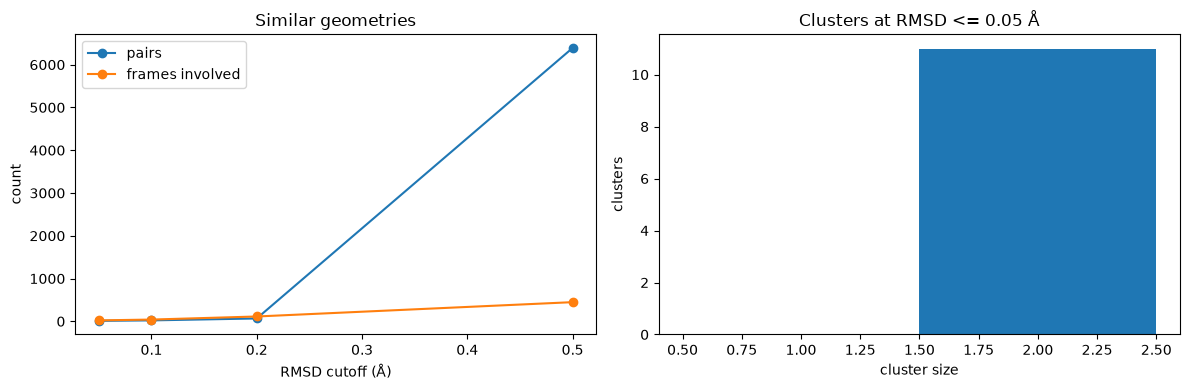

In [15]:
pair_details = (
    similar_pairs
    .merge(frame_metadata, left_on='left_frame', right_on='frame_index', how='left').rename(columns={'azobenzene_isomer': 'left_isomer'}).drop(columns='frame_index')
    .merge(frame_metadata, left_on='right_frame', right_on='frame_index', how='left').rename(columns={'azobenzene_isomer': 'right_isomer'}).drop(columns='frame_index')
)
display(pair_details.head(20))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(summary['rmsd_cutoff_angstrom'], summary['matching_pairs'], marker='o', label='pairs')
axes[0].plot(summary['rmsd_cutoff_angstrom'], summary['frames_involved'], marker='o', label='frames involved')
axes[0].set(xlabel='RMSD cutoff (Å)', ylabel='count', title='Similar geometries')
axes[0].legend()
strict_clusters = cluster_tables[min(RMSD_CUTOFFS_ANGSTROM)]
if len(strict_clusters):
    axes[1].hist(strict_clusters['size'], bins=np.arange(1, strict_clusters['size'].max() + 2) - 0.5)
    axes[1].set(xlabel='cluster size', ylabel='clusters', title=f'Clusters at RMSD <= {min(RMSD_CUTOFFS_ANGSTROM):.2f} Å')
else:
    axes[1].text(0.5, 0.5, 'No matching clusters', ha='center', va='center')
    axes[1].set_axis_off()
plt.tight_layout()
plt.show()